In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('vehicles.csv')
df = df.drop(columns=['id','url','region_url','image_url','description','county','lat','long','vin','region','model'])
df.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,6995,2000.0,gmc,excellent,8 cylinders,gas,167783.0,clean,automatic,4wd,NaN,NaN,red,mn
1,8750,2013.0,hyundai,excellent,4 cylinders,gas,90821.0,clean,automatic,fwd,NaN,NaN,grey,mn
2,10900,2013.0,toyota,good,4 cylinders,hybrid,92800.0,clean,automatic,fwd,NaN,NaN,blue,ct
3,12500,2003.0,mitsubishi,good,4 cylinders,gas,NaN,clean,manual,4wd,mid-size,sedan,grey,nm
4,16995,2007.0,gmc,good,8 cylinders,diesel,254217.0,clean,automatic,4wd,full-size,truck,white,mn


In [3]:
df.isnull().sum()
df=df.dropna(subset=['year','odometer'])
print(df.columns)
df.head()

Index(['price', 'year', 'manufacturer', 'condition', 'cylinders', 'fuel',
       'odometer', 'title_status', 'transmission', 'drive', 'size', 'type',
       'paint_color', 'state'],
      dtype='str')


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,6995,2000.0,gmc,excellent,8 cylinders,gas,167783.0,clean,automatic,4wd,NaN,NaN,red,mn
1,8750,2013.0,hyundai,excellent,4 cylinders,gas,90821.0,clean,automatic,fwd,NaN,NaN,grey,mn
2,10900,2013.0,toyota,good,4 cylinders,hybrid,92800.0,clean,automatic,fwd,NaN,NaN,blue,ct
4,16995,2007.0,gmc,good,8 cylinders,diesel,254217.0,clean,automatic,4wd,full-size,truck,white,mn
5,13995,2012.0,ford,good,6 cylinders,gas,188406.0,clean,automatic,4wd,full-size,truck,grey,mn


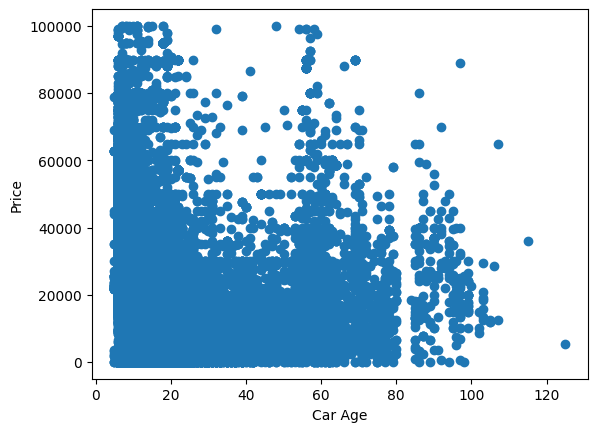

In [4]:
filtered_df = df[
    (df['price'] < 100000) &
    (df['odometer'] < 300000)
]
filtered_df['car_age'] = 2026 - filtered_df['year']
plt.scatter(filtered_df['car_age'], filtered_df['price'])

plt.xlabel("Car Age")
plt.ylabel("Price")

plt.show()

Text(0, 0.5, 'price')

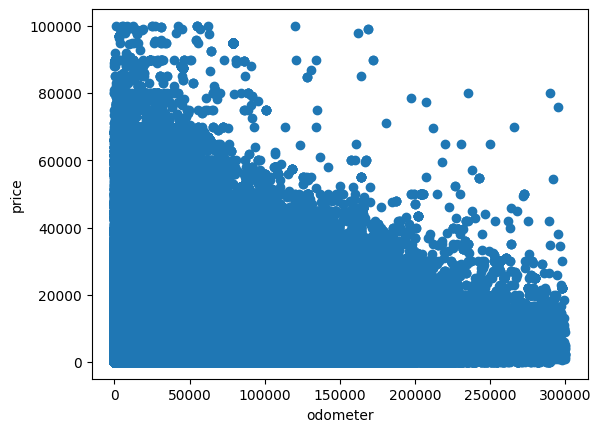

In [5]:
plt.scatter(filtered_df['odometer'], filtered_df['price'])
plt.xlabel('odometer')
plt.ylabel('price')


In [6]:
x = filtered_df[['year', 'odometer','car_age']].values
y = filtered_df['price'].values


In [7]:
def zscore(x):
    mu=x.mean(axis=0)
    sigma=x.std(axis=0)
    x_norm=(x-mu)/sigma
    return x_norm, mu, sigma

In [8]:
print(x.shape)
print(y.shape)


(267340, 3)
(267340,)


In [9]:
def compute_gradient(x,y,w,b):
    m,n=x.shape
    dj_dw = np.zeros(n)
    dj_db=0
    for i in range(m):
        f_wb=np.dot(x[i],w)+b
        err=f_wb-y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * x[i,j]
        dj_db=err+dj_db   
    dj_db=dj_db/m
    dj_dw=dj_dw/m
    return dj_dw,dj_db

In [10]:
def gradient_descent(x,y,w_intial,b_initital,iterators,alpha):
    w=w_intial
    b=b_initital
    for i in range (iterators):
        dj_dw,dj_db=compute_gradient(x,y,w,b)
        w=w-alpha*dj_dw
        b=b-alpha*dj_db
    return w,b

Text(0, 0.5, 'price')

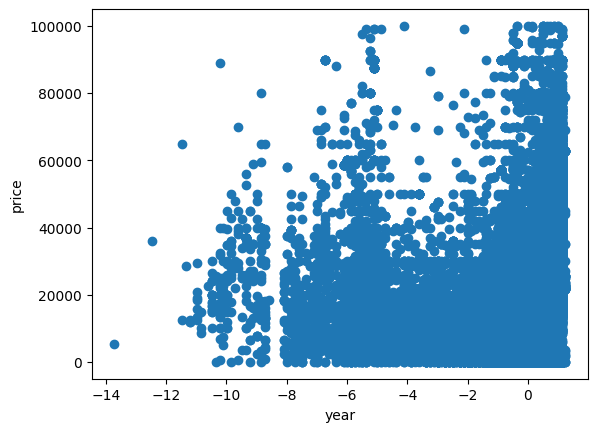

In [11]:
x_norm, mu, sigma = zscore(x)
plt.scatter(x_norm[:,0],y)
plt.xlabel('year')
plt.ylabel('price')

In [35]:
initial_w=np.zeros(x.shape[1])
print(initial_w.shape)
initial_b=0
num_iterators=1000 #may take too much time
alpha=0.01
w_final,b_final=gradient_descent(x_norm,y,initial_w,initial_b,num_iterators,alpha)
print(f"final w = {w_final}, final b = {b_final}")

(3,)
final w = [  948.05321211 -4847.27516607  -948.05321211], final b = 14625.296458806095


In [36]:
print(np.dot(x_norm[1],w_final)+b_final,"actual", y[1])

15470.035758296937 actual 8750


In [37]:
pred=[2016,100000,10]

pred_norm = (pred - mu) / sigma
y_o=np.dot(pred_norm,w_final)+b_final

In [38]:
print(y_o,"$")

15437.82847782311 $


In [39]:
y_pred = np.dot(x_norm, w_final) + b_final

mae = np.mean(np.abs(y_pred - y))

# R² Score
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("MAE =", mae)
print("Mean Price =", np.mean(y))
print("Median Price =", np.median(y))
print("R² =", r2)

MAE = 8211.414852660966
Mean Price = 14625.927878357148
Median Price = 11430.0
R² = 0.1994674186170149
